<a href="https://colab.research.google.com/github/epilef9/clases_ds_ia/blob/trabajo-practico-1-ds/Trabajo_pr%C3%A1ctico_exploraci%C3%B3n_de_dos_variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo práctico: exploración de dos variables

## Declaración previa del análisis (Estudiante: Felipe Correa (37023), Materia: Data Science)

| Campo | Respuesta del estudiante |
|---|---|
| **Código y par elegido** | PC-01 (pickups y temperatura_c). |
| **Pregunta exploratoria** | ¿Cómo varían los pickups por hora junto con la temperatura registrada durante enero de 2024? |
| **Significado de la primera columna** | Representa la cantidad de viajes en Yellow Taxi que efectivamente se realizaron, se reportaron y pasaron los filtros de calidad en una hora determinada. |
| **Significado de la segunda columna** | Representa la temperatura media en grados Celsius registrada por la estación meteorológica en esa misma hora. |
| **Tipo semántico de cada columna** | *Pickups*: Magnitud numérica (conteo de viajes).<br>*Temperatura_c*: Magnitud numérica continua (grados). |
| **Unidad analítica y vista** | Vista H: Una fila representa una hora de enero. |
| **Periodo y zona horaria** | [2024-01-01, 2024-02-01) en la zona America/New_York. |
| **Población registrada** | Viajes de Yellow Taxi realizados y reportados, y observaciones meteorológicas de una única estación de NOAA. |
| **Denominador o tamaño válido** | Cantidad total de horas en enero de 2024 (aprox. 744) que tengan registros válidos tras la unión de ambos conjuntos de datos. |
| **Afirmaciones que los datos no permiten** | Los datos no permiten establecer relaciones causales (ej: probar que el calor "cause" viajes), no reflejan la demanda total (no incluye viajes no atendidos) y no permiten analizar variaciones de temperatura entre distintas zonas de la ciudad (porque es una única estación meteorológica). |

# Taller de movilidad urbana: taxis y clima en Nueva York

**Caso de estudio:** viajes de NYC TLC Yellow Taxi durante enero de 2024.

En este taller construiremos un flujo reproducible: adquisición, inspección, auditoría de calidad, enriquecimiento por zonas, agregación temporal, integración con clima y análisis exploratorio. No buscamos demostrar causalidad, sino aprender a formular y comprobar preguntas con datos reales.

## Objetivos

Al finalizar podrás:

- construir y validar una URL de datos abiertos;
- inspeccionar estructura, tipos y faltantes antes de analizar;
- convertir reglas de calidad en una tabla de auditoría;
- enriquecer viajes mediante uniones `many_to_one`;
- agregar pickups por zona y hora sin sesgar la serie temporal;
- convertir observaciones meteorológicas de UTC a `America/New_York`;
- comunicar patrones y límites de un análisis exploratorio.

> **Pregunta guía:** ¿cómo varían los pickups de Yellow Taxi por lugar y hora, y qué relación exploratoria muestran con temperatura y precipitación?

## Ficha de fuentes

| Fuente | Recurso usado | Papel en el taller |
|---|---|---|
| [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Yellow Taxi, enero de 2024 (`yellow_tripdata_2024-01.parquet`) | fecha/hora, zonas, distancia, pasajeros e importes de viajes reportados |
| NYC TLC | [Taxi Zone Lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv) | traduce `LocationID` a borough, zona y `service_zone` |
| NYC TLC | [Taxi Zone Shapefile](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip) | geometrías para la extensión espacial opcional |
| [NOAA GHCNh](https://www.ncei.noaa.gov/products/global-historical-climatology-network-hourly) | estación `USW00094728`, año 2024 | observaciones de clima con marcas temporales UTC |

**Periodo común:** enero de 2024 en hora local de Nueva York. Los archivos se leen desde sus URL o desde un directorio temporal; este notebook no guarda datasets en el repositorio. Consulta la documentación y licencias de cada proveedor antes de reutilizar los datos.

## 1. Preparación y modo de ejecución

En Colab normalmente basta con ejecutar los imports. Si falta el motor Parquet, descomenta la instalación. La extensión espacial se instala solo si se desea ejecutar esa sección.

In [1]:
# Instalación opcional para Google Colab/Jupyter (descomentar si hace falta):
# %pip install -q pyarrow
# %pip install -q geopandas folium requests

from io import StringIO
import tempfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# True: primera semana de enero; False: todo enero. No hay muestreo aleatorio.
MODO_CLASE = False
INICIO_MES = pd.Timestamp("2024-01-01")
FIN_MES = pd.Timestamp("2024-02-01")
FIN_ANALISIS = pd.Timestamp("2024-01-08") if MODO_CLASE else FIN_MES
ZONA_HORARIA = "America/New_York"

print(f"Ventana: {INICIO_MES} hasta {FIN_ANALISIS} (fin no incluido)")

Ventana: 2024-01-01 00:00:00 hasta 2024-02-01 00:00:00 (fin no incluido)


`MODO_CLASE` limita la lectura mediante un filtro temporal de Parquet cuando el motor lo permite. La selección es una semana completa y determinista, no una muestra aleatoria: así preservamos horas consecutivas y el flujo de agregación. En modo completo, la misma lógica procesa todo enero.

## 2. URL validada y carga reproducible

In [3]:
def construir_url_tlc(tipo, anio, mes):
    """Construye una URL TLC válida para un tipo, año y mes."""
    prefijos = {
        "yellow": "yellow_tripdata",
        "green": "green_tripdata",
        "fhv": "fhv_tripdata",
        "fhvhv": "fhvhv_tripdata",
    }
    if tipo not in prefijos:
        opciones = ", ".join(prefijos)
        raise ValueError(f"tipo debe ser uno de: {opciones}")
    if isinstance(anio, bool) or not isinstance(anio, (int, np.integer)) or not 2009 <= anio <= 2100:
        raise ValueError("anio debe ser un entero entre 2009 y 2100")
    if isinstance(mes, bool) or not isinstance(mes, (int, np.integer)) or not 1 <= mes <= 12:
        raise ValueError("mes debe ser un entero entre 1 y 12")
    archivo = f"{prefijos[tipo]}_{anio}-{mes:02d}.parquet"
    return f"https://d37ci6vzurychx.cloudfront.net/trip-data/{archivo}"

URL_VIAJES = construir_url_tlc("yellow", 2024, 1)
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_GEOMETRIAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
URL_CLIMA = (
    "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/"
    "hourly/access/by-year/2024/psv/GHCNh_USW00094728_2024.psv"
)
print(URL_VIAJES)

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [4]:
COLUMNAS_VIAJES = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "PULocationID",
    "DOLocationID", "fare_amount", "total_amount",
]
filtros = [
    ("tpep_pickup_datetime", ">=", INICIO_MES.to_pydatetime()),
    ("tpep_pickup_datetime", "<", FIN_ANALISIS.to_pydatetime()),
]

# PyArrow aplica el filtro por fecha al leer los grupos de filas compatibles.
viajes_originales = pd.read_parquet(
    URL_VIAJES, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow"
)
print(f"Viajes cargados: {len(viajes_originales):,}")

Viajes cargados: 2,964,606


### Pregunta breve

¿Por qué una semana consecutiva es preferible a una muestra aleatoria si queremos comparar horas y días? Escribe una hipótesis antes de continuar.

<details><summary>Ver respuesta orientativa</summary>Una muestra aleatoria puede dejar horas incompletas y alterar sus conteos. Una ventana consecutiva conserva el orden, los ciclos diarios y el denominador temporal, aunque no necesariamente representa el mes completo.</details>

## 3. Inspección antes de limpiar

No debemos decidir reglas sin conocer el esquema. Observa dimensiones, ejemplos, tipos y faltantes.

In [5]:
print("Shape:", viajes_originales.shape)
display(viajes_originales.head())
print("\nInfo:")
viajes_originales.info()
print("\nTipos:")
display(viajes_originales.dtypes.rename("dtype").to_frame())

faltantes = (
    viajes_originales.isna().sum().rename("n_faltantes").to_frame()
    .assign(porcentaje=lambda x: 100 * x["n_faltantes"] / len(viajes_originales))
    .sort_values("porcentaje", ascending=False)
)
display(faltantes)

Shape: (2964606, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964606 entries, 0 to 2964605
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(4), int32(2)
memory usage: 158.3 MB

Tipos:


,dtype
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
PULocationID,int32
DOLocationID,int32
fare_amount,float64
total_amount,float64


,n_faltantes,porcentaje
passenger_count,140162,4.727846
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
trip_distance,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
fare_amount,0,0.000000
total_amount,0,0.000000


**Observa:** `passenger_count` puede faltar por la forma de reporte. Su ausencia se conserva y no invalida automáticamente un viaje. Solo marcaremos como problemáticos los valores presentes fuera de un intervalo operativo razonable.

## 4. Calidad y auditoría

Las reglas siguientes son criterios analíticos, no verdades universales. Distancia máxima de 100 millas, hasta 8 pasajeros e importes menores a USD 1,000 son umbrales conservadores para detectar registros extremos o inválidos. Cada regla queda en una columna booleana.

In [6]:
calidad = viajes_originales.copy()
calidad["duracion_min"] = (
    calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]
).dt.total_seconds() / 60

calidad["ok_pickup"] = calidad["tpep_pickup_datetime"].notna() & calidad["tpep_pickup_datetime"].between(INICIO_MES, FIN_ANALISIS, inclusive="left")
calidad["ok_dropoff"] = calidad["tpep_dropoff_datetime"].notna()
calidad["ok_duracion"] = calidad["duracion_min"].gt(0) & calidad["duracion_min"].le(24 * 60)
calidad["ok_distancia"] = calidad["trip_distance"].between(0, 100, inclusive="both")
calidad["ok_id_pickup_presente"] = calidad["PULocationID"].notna()
calidad["ok_id_dropoff_presente"] = calidad["DOLocationID"].notna()
calidad["ok_importes"] = (
    calidad["fare_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].ge(calidad["fare_amount"])
)
calidad["ok_pasajeros"] = calidad["passenger_count"].isna() | calidad["passenger_count"].between(0, 8, inclusive="both")

REGLAS = [c for c in calidad.columns if c.startswith("ok_")]
calidad["registro_valido"] = calidad[REGLAS].all(axis=1)
auditoria = pd.DataFrame({
    "regla": REGLAS,
    "cumplen": [int(calidad[c].sum()) for c in REGLAS],
    "incumplen": [int((~calidad[c]).sum()) for c in REGLAS],
})
auditoria["porcentaje_incumple"] = 100 * auditoria["incumplen"] / len(calidad)
display(auditoria.sort_values("porcentaje_incumple", ascending=False))

,regla,cumplen,incumplen,porcentaje_incumple
6,ok_importes,2927032,37574,1.267420
2,ok_duracion,2963720,886,0.029886
3,ok_distancia,2964547,59,0.001990
7,ok_pasajeros,2964605,1,0.000034
0,ok_pickup,2964606,0,0.000000
1,ok_dropoff,2964606,0,0.000000
5,ok_id_dropoff_presente,2964606,0,0.000000
4,ok_id_pickup_presente,2964606,0,0.000000


In [7]:
# Se mantienen por separado para no borrar silenciosamente información.
viajes_rechazados = calidad.loc[~calidad["registro_valido"]].copy()
viajes_validos = calidad.loc[calidad["registro_valido"]].copy()
print(f"Válidos: {len(viajes_validos):,} | Rechazados: {len(viajes_rechazados):,}")
display(viajes_rechazados[COLUMNAS_VIAJES + ["duracion_min"] + REGLAS].head())

Válidos: 2,926,101 | Rechazados: 38,505


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,duracion_min,ok_pickup,ok_dropoff,ok_duracion,ok_distancia,ok_id_pickup_presente,ok_id_dropoff_presente,ok_importes,ok_pasajeros
23,2024-01-01 00:14:29,2024-01-01 00:14:29,1.0,0.00,236,264,3.0,8.00,0.000000,True,True,False,True,True,True,True,True
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,249,232,-13.5,-18.50,12.250000,True,True,True,True,True,True,False,True
504,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,63,63,-31.5,-34.25,0.733333,True,True,True,True,True,True,False,True
534,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,249,113,-5.8,-10.80,4.300000,True,True,True,True,True,True,False,True
550,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,107,61,-33.1,-38.10,32.516667,True,True,True,True,True,True,False,True


### Ejercicio 1: sensibilidad de una regla

Calcula cuántos viajes quedarían fuera si la distancia máxima fuese 50 millas, sin modificar `viajes_validos`.

In [8]:
# Tu respuesta:
# fuera_con_umbral_50 = ...

<details><summary>Ver solución</summary>

```python
fuera_con_umbral_50 = (~calidad["trip_distance"].between(0, 50)).sum()
print(fuera_con_umbral_50)
```

Conviene comparar este resultado con `ok_distancia` y justificar el umbral con conocimiento del dominio.
</details>

## 5. Enriquecimiento con zonas

### Objetivo

La tabla de viajes identifica el origen mediante `PULocationID` y el destino mediante `DOLocationID`. Estos códigos son útiles para relacionar tablas, pero no permiten interpretar directamente dónde comenzó o terminó un viaje.

En esta sección agregaremos a cada viaje el nombre de la zona, el borough y la clasificación de servicio tanto del origen como del destino. Conceptualmente:

```text
PULocationID = 161
        ↓
pickup_zone = Midtown Center
pickup_borough = Manhattan
pickup_service_zone = Yellow Zone
```

El enriquecimiento no cambia la unidad de observación: cada fila continúa representando un viaje Yellow Taxi reportado. Solo agrega contexto geográfico a sus identificadores.

### 5.1. El catálogo de zonas

`taxi_zone_lookup.csv` es un **catálogo de correspondencias** publicado por NYC TLC. No contiene viajes: contiene una descripción por `LocationID`.

| Columna | Significado |
|---|---|
| `LocationID` | Identificador numérico de la zona TLC |
| `Borough` | Distrito amplio, como Manhattan, Queens o Brooklyn |
| `Zone` | Nombre específico de la zona TLC |
| `service_zone` | Clasificación operativa, como `Yellow Zone`, `Boro Zone` o `Airports` |

Para que el catálogo pueda representar el lado **uno** de una unión, `LocationID` debe ser único.

In [9]:
zonas = pd.read_csv(URL_ZONAS)
display(zonas.head())
print("Cantidad de zonas:", len(zonas))
print("LocationID es único:", zonas["LocationID"].is_unique)

if zonas["LocationID"].duplicated().any():
    raise ValueError("Taxi Zone Lookup contiene LocationID duplicados")

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Cantidad de zonas: 265
LocationID es único: True


### 5.2. Un catálogo, dos roles

Cada viaje consulta el mismo catálogo desde dos papeles diferentes:

```text
PULocationID → zona de origen o pickup
DOLocationID → zona de destino o dropoff
```

Por eso creamos `zonas_pickup` y `zonas_dropoff`. No son dos catálogos distintos ni duplican los viajes: son dos versiones del mismo catálogo con nombres que explicitan el rol de sus columnas.

| Origen | Destino |
|---|---|
| `pickup_zone` | `dropoff_zone` |
| `pickup_borough` | `dropoff_borough` |
| `pickup_service_zone` | `dropoff_service_zone` |

Renombrar antes de unir evita nombres ambiguos como `Zone_x` y `Zone_y`. `DataFrame.rename()` devuelve estas versiones adaptadas sin modificar `zonas`.

In [10]:
zonas_pickup = zonas.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough",
    "Zone": "pickup_zone", "service_zone": "pickup_service_zone",
})
zonas_dropoff = zonas.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough",
    "Zone": "dropoff_zone", "service_zone": "dropoff_service_zone",
})

display(zonas_pickup.head(2))
display(zonas_dropoff.head(2))

,PULocationID,pickup_borough,pickup_zone,pickup_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


### 5.3. Cardinalidad `many_to_one`

La relación esperada es **muchos viajes → una descripción de zona**. Un mismo `PULocationID` o `DOLocationID` puede aparecer en miles de viajes, pero cada identificador debe aparecer como máximo una vez en el catálogo correspondiente.

`validate="many_to_one"` hace que pandas compruebe esta condición durante la unión. Si el catálogo tuviera dos filas para `LocationID = 161`, tres viajes con ese identificador producirían seis filas:

```text
3 viajes × 2 coincidencias en el catálogo = 6 filas
```

Esa multiplicación inflaría conteos, importes, promedios y mapas. La validación detiene el proceso con un error en lugar de producir silenciosamente un resultado incorrecto. También ayuda a detectar catálogos repetidos, mezcla de versiones o descripciones contradictorias para un mismo ID.

### 5.4. Dos uniones izquierdas

Primero agregamos los atributos del origen y después los del destino. `how="left"` conserva todos los viajes válidos. Si un ID no aparece en el catálogo, el viaje permanece y sus atributos geográficos quedan como `NaN`, lo que permite auditar la falta de correspondencia en vez de eliminarla silenciosamente.

In [11]:
viajes_zonas = (
    viajes_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    .merge(zonas_dropoff, on="DOLocationID", how="left", validate="many_to_one")
)

### 5.5. Controles posteriores e interpretación

Después de unir comprobamos dos propiedades diferentes:

1. **Conservación de filas:** la cantidad de viajes no debe cambiar.
2. **Cobertura del catálogo:** contamos los viajes cuyo ID no encontró nombre de zona.

`many_to_one` no garantiza cobertura completa ni detecta viajes duplicados, IDs faltantes, nombres incorrectos en una fila única o el uso de la clave equivocada. Por eso se complementa con estos controles y con la revisión semántica de las columnas obtenidas.

In [12]:
assert len(viajes_zonas) == len(viajes_validos), "La unión cambió el número de viajes"

sin_nombre_pickup = viajes_zonas["pickup_zone"].isna().sum()
sin_nombre_dropoff = viajes_zonas["dropoff_zone"].isna().sum()
print("Viajes antes y después:", len(viajes_validos), len(viajes_zonas))
print("Sin zona pickup:", sin_nombre_pickup, "| Sin zona dropoff:", sin_nombre_dropoff)

COLUMNAS_ZONA = [
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
]
display(viajes_zonas[COLUMNAS_ZONA].head())

Viajes antes y después: 2926101 2926101
Sin zona pickup: 10177 | Sin zona dropoff: 15295


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,79,Manhattan,East Village,Yellow Zone
1,140,Manhattan,Lenox Hill East,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
2,236,Manhattan,Upper East Side North,Yellow Zone,79,Manhattan,East Village,Yellow Zone
3,79,Manhattan,East Village,Yellow Zone,211,Manhattan,SoHo,Yellow Zone
4,211,Manhattan,SoHo,Yellow Zone,148,Manhattan,Lower East Side,Yellow Zone


### Resultado de la sección

Cada fila sigue representando un viaje, pero ahora permite interpretar tanto su origen como su destino. Las zonas son áreas geográficas agregadas definidas por TLC: no indican una dirección ni una coordenada exacta, y el enriquecimiento no agrega demanda total, solicitudes no atendidas ni vehículos disponibles.

### Pregunta breve

¿Qué ocurriría si `LocationID = 161` apareciera dos veces en el catálogo y no utilizáramos `validate="many_to_one"`?

<details><summary>Ver respuesta orientativa</summary>Cada viaje con ese identificador encontraría dos coincidencias y aparecería dos veces en el resultado. Los conteos y agregaciones posteriores quedarían inflados. Con `validate="many_to_one"`, pandas detecta que el lado del catálogo no es único y detiene la unión.</details>

## 6. Agregación zona-hora de pickups

Los timestamps TLC se interpretan como hora local. En enero de 2024 no hay transición de horario de verano, pero explicitar la zona horaria evita una unión ambigua con NOAA.

In [13]:
viajes_zonas["pickup_hora"] = (
    viajes_zonas["tpep_pickup_datetime"]
    .dt.tz_localize(ZONA_HORARIA, ambiguous="raise", nonexistent="raise")
    .dt.floor("h")
)
pickups_zona_hora = (
    viajes_zonas.groupby(
        ["pickup_hora", "PULocationID", "pickup_borough", "pickup_zone"],
        observed=True, dropna=False,
    )
    .size().rename("pickups").reset_index()
)
assert pickups_zona_hora.duplicated(["pickup_hora", "PULocationID"]).sum() == 0
display(pickups_zona_hora.head())

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4


## 7. Clima: UTC, hora local y resumen horario

GHCNh puede contener varias observaciones dentro de una hora. Seleccionaremos variables numéricas, convertiremos valores no numéricos a faltantes y resumiremos a una fila por hora. Temperatura usa media; precipitación usa suma con `min_count=1` para no convertir una hora totalmente faltante en cero.

In [14]:
COLUMNAS_CLIMA = [
    "STATION", "Station_name", "DATE", "temperature",
    "relative_humidity", "wind_speed", "precipitation", "visibility",
]
with urlopen(URL_CLIMA) as respuesta:
    texto_clima = respuesta.read().decode("utf-8")
clima_bruto = pd.read_csv(StringIO(texto_clima), sep="|", usecols=COLUMNAS_CLIMA, low_memory=False)
assert clima_bruto["STATION"].astype(str).eq("USW00094728").all()
print("Observaciones meteorológicas cargadas:", len(clima_bruto))

Observaciones meteorológicas cargadas: 11222


In [15]:
clima = clima_bruto.copy()
clima["fecha_utc"] = pd.to_datetime(clima["DATE"], utc=True, errors="coerce")
clima["fecha_ny"] = clima["fecha_utc"].dt.tz_convert(ZONA_HORARIA)
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
clima = clima.loc[clima["fecha_ny"].between(inicio_local, fin_local, inclusive="left")].copy()

VARIABLES_CLIMA = ["temperature", "relative_humidity", "wind_speed", "precipitation", "visibility"]
clima[VARIABLES_CLIMA] = clima[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima["hora"] = clima["fecha_ny"].dt.floor("h")
clima_horario = (
    clima.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
        humedad_relativa=("relative_humidity", "mean"),
        viento=("wind_speed", "mean"),
        precipitacion_mm=("precipitation", lambda s: s.sum(min_count=1)),
        visibilidad=("visibility", "mean"),
        observaciones=("fecha_ny", "size"),
    )
)
if clima_horario["hora"].duplicated().any():
    raise ValueError("El resumen climático no es único por hora")
display(clima_horario.head())

,hora,temperatura_c,humedad_relativa,viento,precipitacion_mm,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1
1,2024-01-01 01:00:00-05:00,5.6,58.0,2.1,0.0,16.093,1
2,2024-01-01 02:00:00-05:00,5.0,60.0,0.0,0.0,16.093,1
3,2024-01-01 03:00:00-05:00,5.0,62.0,1.5,0.0,16.093,1
4,2024-01-01 04:00:00-05:00,4.4,68.0,0.0,0.0,16.093,1


### Ejercicio 2: cobertura temporal

Compara las horas esperadas de la ventana con las horas observadas en `clima_horario`. ¿Hay huecos?

In [16]:
# Tu respuesta:
# horas_esperadas = ...
# horas_sin_clima = ...

<details><summary>Ver solución</summary>

```python
horas_esperadas = pd.date_range(inicio_local, fin_local, freq="h", inclusive="left")
horas_sin_clima = horas_esperadas.difference(clima_horario["hora"])
print("Horas esperadas:", len(horas_esperadas))
print("Horas sin observación:", len(horas_sin_clima))
display(horas_sin_clima[:10])
```
</details>

## 8. Unión zona-hora con clima

Cada fila zona-hora debe encontrar como máximo una fila climática. La unión izquierda conserva los pickups aunque el clima falte.

In [17]:
zona_hora_clima = pickups_zona_hora.merge(
    clima_horario, left_on="pickup_hora", right_on="hora",
    how="left", validate="many_to_one", indicator=True,
)
assert len(zona_hora_clima) == len(pickups_zona_hora), "La unión alteró la cardinalidad izquierda"
auditoria_union = zona_hora_clima["_merge"].value_counts(dropna=False).rename_axis("resultado").to_frame("filas")
display(auditoria_union)
zona_hora_clima = zona_hora_clima.drop(columns="_merge")

,filas
resultado,
both,77335
left_only,131
right_only,0


### ¿Por qué el clima queda repetido por zona?

La unidad de `zona_hora_clima` es **una zona en una hora**. En cambio, `clima_horario` contiene una sola observación por hora. Cuando esa observación se une con varias zonas de la misma hora, pandas la copia en cada fila zona-hora.

Ejemplo conceptual:

| zona | hora | pickups | temperatura |
|---|---|---:|---:|
| A | 08:00 | 20 | 5 °C |
| B | 08:00 | 35 | 5 °C |
| C | 08:00 | 15 | 5 °C |

Los tres valores de `5 °C` no son mediciones diferentes: son la misma observación meteorológica replicada por la unión `many_to_one`. Esta repetición es intencional, no un duplicado accidental. Además, NOAA representa una estación meteorológica; no estamos estimando un clima diferente para cada zona.

## 9. Análisis exploratorio con pandas y matplotlib

Lee cada gráfico como evidencia descriptiva. Pregunta siempre: ¿qué unidad representa?, ¿qué filtros se aplicaron?, ¿qué explicación alternativa existe?

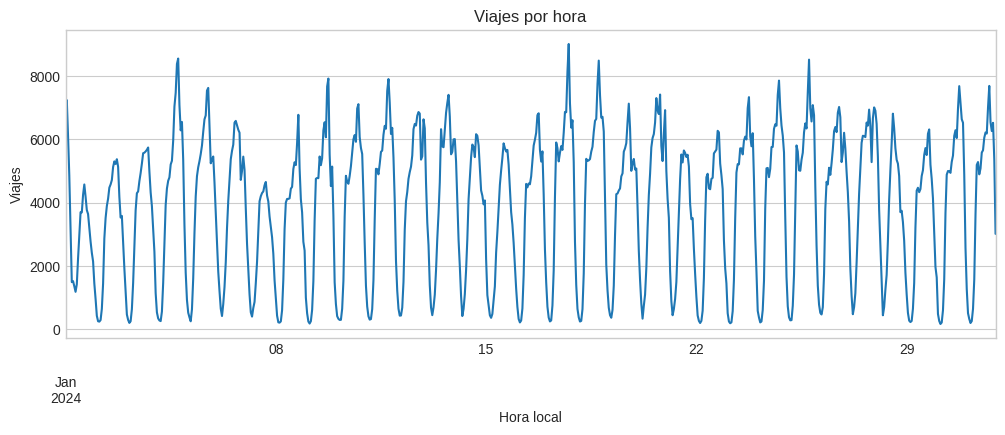

In [18]:
viajes_por_hora = viajes_zonas.set_index("pickup_hora").resample("h").size()
ax = viajes_por_hora.plot(figsize=(12, 4), color="#1f77b4", linewidth=1.5)
ax.set(title="Viajes por hora", xlabel="Hora local", ylabel="Viajes")
plt.show()

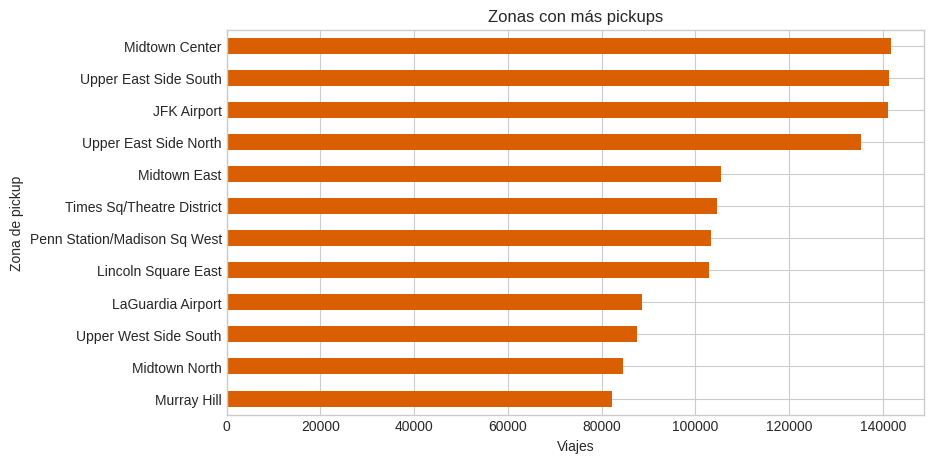

,pickups
pickup_zone,
Midtown Center,141714
Upper East Side South,141237
JFK Airport,141107
Upper East Side North,135303
Midtown East,105440
Times Sq/Theatre District,104590
Penn Station/Madison Sq West,103254
Lincoln Square East,102960
LaGuardia Airport,88556


In [19]:
top_zonas = viajes_zonas["pickup_zone"].value_counts().head(12).sort_values()
ax = top_zonas.plot.barh(figsize=(9, 5), color="#d95f02")
ax.set(title="Zonas con más pickups", xlabel="Viajes", ylabel="Zona de pickup")
plt.show()
display(top_zonas.sort_values(ascending=False).rename("pickups").to_frame())

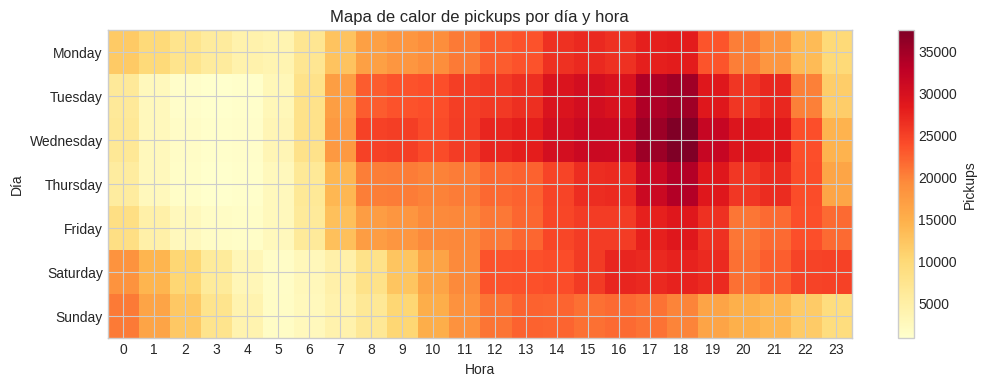

In [20]:
patron = viajes_zonas.assign(
    dia=viajes_zonas["pickup_hora"].dt.day_name(),
    hora_dia=viajes_zonas["pickup_hora"].dt.hour,
).pivot_table(index="dia", columns="hora_dia", values="PULocationID", aggfunc="size", fill_value=0)
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
patron = patron.reindex([d for d in orden_dias if d in patron.index])
fig, ax = plt.subplots(figsize=(12, 4))
imagen = ax.imshow(patron, aspect="auto", cmap="YlOrRd")
ax.set(title="Mapa de calor de pickups por día y hora", xlabel="Hora", ylabel="Día")
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(patron.index)), labels=patron.index)
fig.colorbar(imagen, ax=ax, label="Pickups")
plt.show()

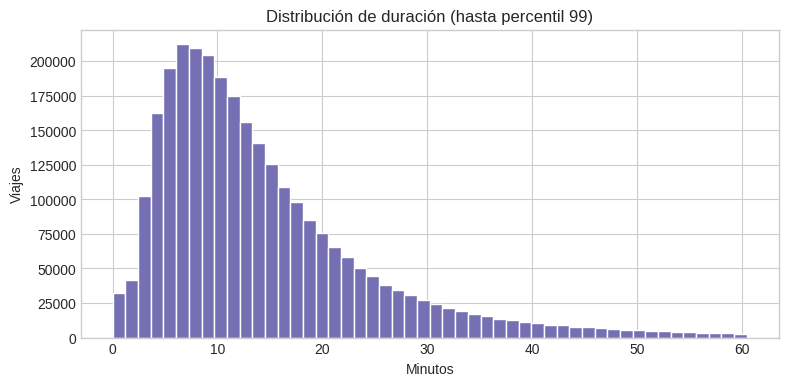

Percentil 99 mostrado: 60.5 minutos


In [21]:
limite_99 = viajes_validos["duracion_min"].quantile(0.99)
ax = viajes_validos.loc[viajes_validos["duracion_min"] <= limite_99, "duracion_min"].plot.hist(
    bins=50, figsize=(9, 4), color="#7570b3", edgecolor="white"
)
ax.set(title="Distribución de duración (hasta percentil 99)", xlabel="Minutos", ylabel="Viajes")
plt.show()
print("Percentil 99 mostrado:", round(limite_99, 1), "minutos")

### 9.1. De zona-hora a una observación por hora

Para comparar la actividad total de taxis con el clima debemos volver de la unidad **zona-hora** a la unidad **hora**. En el ejemplo anterior:

```text
pickups = 20 + 35 + 15 = 70
temperatura = 5 °C
```

Por eso usamos operaciones diferentes:

- `sum` para `pickups`, porque cada zona aporta viajes distintos;
- `first` para temperatura y precipitación, porque cada fila contiene una copia del mismo clima horario.

Sumar la temperatura produciría `5 + 5 + 5 = 15 °C`, un valor sin interpretación física. El uso de `first` requiere comprobar antes que una misma hora no contenga valores climáticos diferentes entre zonas.

Consistencia climática por hora: OK


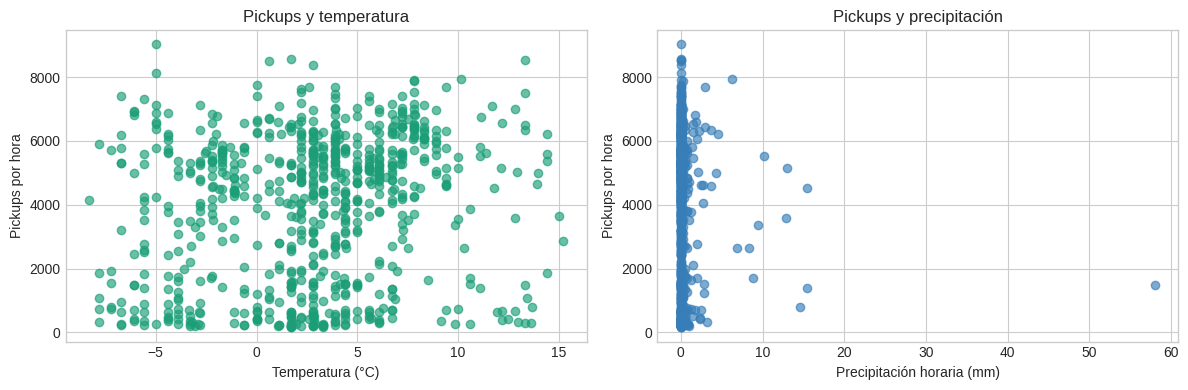

,pickups,temperatura_c,precipitacion_mm
pickups,1.000,0.158,-0.054
temperatura_c,0.158,1.000,0.193
precipitacion_mm,-0.054,0.193,1.000


In [22]:
# Verificamos el supuesto necesario para conservar una sola copia con 'first'.
variables_clima_repetidas = ["temperatura_c", "precipitacion_mm"]
consistencia_clima = (
    zona_hora_clima
    .groupby("pickup_hora")[variables_clima_repetidas]
    .nunique(dropna=False)
)
assert consistencia_clima.le(1).all().all(), (
    "Una misma hora contiene valores climáticos diferentes entre zonas"
)
print("Consistencia climática por hora: OK")

# El clima está repetido por zona; volvemos a una observación por hora.
comparacion_horaria = (
    zona_hora_clima.groupby("pickup_hora", as_index=False)
    .agg(
        pickups=("pickups", "sum"),
        temperatura_c=("temperatura_c", "first"),
        precipitacion_mm=("precipitacion_mm", "first"),
    )
)
assert not comparacion_horaria["pickup_hora"].duplicated().any()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(comparacion_horaria["temperatura_c"], comparacion_horaria["pickups"], alpha=0.65, color="#1b9e77")
axes[0].set(xlabel="Temperatura (°C)", ylabel="Pickups por hora", title="Pickups y temperatura")
axes[1].scatter(comparacion_horaria["precipitacion_mm"], comparacion_horaria["pickups"], alpha=0.65, color="#377eb8")
axes[1].set(xlabel="Precipitación horaria (mm)", ylabel="Pickups por hora", title="Pickups y precipitación")
plt.tight_layout()
plt.show()
display(comparacion_horaria[["pickups", "temperatura_c", "precipitacion_mm"]].corr().round(3))

### Pregunta breve

¿Qué ocurriría si sumáramos la temperatura después de haberla replicado por zona?

<details><summary>Ver respuesta orientativa</summary>La misma observación se contabilizaría varias veces y produciría una temperatura sin interpretación física. Los pickups sí se suman porque cada zona aporta viajes diferentes; el clima se conserva una sola vez porque es el mismo valor replicado.</details>

### Ejercicio 3: interpretar sin exagerar

Escribe dos observaciones de los gráficos y una explicación alternativa. Evita frases causales como “la lluvia provoca...”.

**Tu respuesta:**

1. ...
2. ...
3. Explicación alternativa: ...

<details><summary>Ver pauta de solución</summary>Una respuesta sólida identifica dirección, magnitud o franjas horarias, menciona la ventana analizada y reconoce factores de confusión como hora pico, día de semana, aeropuerto, feriados o disponibilidad de taxis. Una correlación horaria no permite atribuir causalidad al clima.</details>

## 10. Exportar el producto fuera del repositorio

Antes de exportar comprobamos la clave, ordenamos el producto y usamos el directorio temporal del sistema. El nombre distingue el modo de clase del mes completo para no declarar una cobertura que no fue procesada.

In [23]:
producto = zona_hora_clima.sort_values(["pickup_hora", "PULocationID"]).copy()
if producto.duplicated(["pickup_hora", "PULocationID"]).any():
    raise ValueError("La clave zona-hora no es única")

alcance = "primera_semana_enero_2024" if MODO_CLASE else "enero_2024"
ruta_producto = Path(tempfile.gettempdir()) / f"zona_hora_{alcance}.parquet"
producto.to_parquet(ruta_producto, index=False)
print("Producto temporal:", ruta_producto)
print("Unidad: zona de origen-hora local | Zona horaria:", ZONA_HORARIA)

Producto temporal: /tmp/zona_hora_enero_2024.parquet
Unidad: zona de origen-hora local | Zona horaria: America/New_York


## 11. Extensión espacial opcional

Esta celda descarga el ZIP del shapefile a un directorio temporal, extrae juntos sus componentes (`.shp`, `.dbf`, `.shx`, `.prj`) y construye un mapa Folium. La extracción explícita evita depender de que el backend geoespacial admita rutas virtuales `zip://`; al finalizar, el directorio temporal se elimina y no deja geometrías en el repositorio. Si `geopandas`, `folium` o `requests` no están instalados, informa exactamente cómo habilitar la sección y el resto del taller sigue siendo utilizable.

In [ ]:
try:
    import folium
    import geopandas as gpd
    import requests
    import zipfile
except ModuleNotFoundError as error:
    print(
        f"Sección espacial omitida: falta '{error.name}'. "
        "Descomenta `%pip install -q geopandas folium requests`, reinicia si es necesario y vuelve a ejecutar."
    )
else:
    with tempfile.TemporaryDirectory() as directorio_base:
        ruta_zip = Path(directorio_base) / "taxi_zones.zip"
        respuesta = requests.get(URL_GEOMETRIAS, timeout=60)
        respuesta.raise_for_status()
        ruta_zip.write_bytes(respuesta.content)
        if not zipfile.is_zipfile(ruta_zip):
            raise zipfile.BadZipFile("La descarga de zonas TLC no es un archivo ZIP válido")

        directorio_extraido = Path(directorio_base) / "taxi_zones_extraido"
        directorio_extraido.mkdir()
        with zipfile.ZipFile(ruta_zip) as archivo_zip:
            archivo_zip.extractall(directorio_extraido)

        archivos_shp = sorted(directorio_extraido.rglob("*.shp"))
        if not archivos_shp:
            raise FileNotFoundError("No se encontró un archivo .shp dentro del ZIP de zonas TLC")
        ruta_shp = next((ruta for ruta in archivos_shp if ruta.name == "taxi_zones.shp"), archivos_shp[0])
        geo_zonas = gpd.read_file(ruta_shp).to_crs(epsg=4326)

    pickups_mapa = viajes_zonas["PULocationID"].value_counts().rename("pickups").reset_index()
    geo_zonas["LocationID"] = pd.to_numeric(geo_zonas["LocationID"])
    geo_mapa = geo_zonas.merge(pickups_mapa, left_on="LocationID", right_on="PULocationID", how="left", validate="one_to_one")
    geo_mapa["pickups"] = geo_mapa["pickups"].fillna(0)
    min_x, min_y, max_x, max_y = geo_mapa.total_bounds
    centro = [(min_y + max_y) / 2, (min_x + max_x) / 2]
    mapa = folium.Map(location=centro, zoom_start=10, tiles="CartoDB positron")
    folium.Choropleth(
        geo_data=geo_mapa, data=geo_mapa, columns=["LocationID", "pickups"],
        key_on="feature.properties.LocationID", fill_color="YlOrRd",
        fill_opacity=0.7, line_opacity=0.3, legend_name="Pickups",
    ).add_to(mapa)
    folium.GeoJson(
        geo_mapa, style_function=lambda _: {"fillOpacity": 0, "weight": 0},
        tooltip=folium.GeoJsonTooltip(fields=["zone", "borough", "pickups"], aliases=["Zona", "Borough", "Pickups"]),
    ).add_to(mapa)
    display(mapa)

## 12. Conclusiones y límites

**Qué construimos**

- un proceso reproducible para enero de 2024, escalable de una semana al mes;
- una auditoría que hace visibles los criterios de exclusión;
- una tabla zona-hora enriquecida con clima mediante cardinalidad comprobada;
- visualizaciones temporales, espaciales y de asociación exploratoria.

**Límites que deben acompañar cualquier conclusión**

- Los registros son **viajes reportados de Yellow Taxi**, no demanda total, viajes no atendidos ni toda la movilidad de Nueva York.
- Una sola estación, `USW00094728`, no representa toda la variación meteorológica espacial de la ciudad.
- La cobertura y frecuencia de GHCNh pueden variar; resumir precipitación subhoraria exige revisar la documentación de medición.
- Las reglas de calidad y sus umbrales afectan los resultados y deben justificarse.
- La asociación entre pickups y clima está confundida por hora, día, localización, oferta, eventos y otros factores. **Correlación no implica causalidad.**
- `MODO_CLASE=True` describe solo la primera semana; para conclusiones mensuales se debe ejecutar el mes completo y evaluar estabilidad.

**Cierre:** ¿qué dato adicional pedirías para distinguir mejor demanda, oferta y viajes efectivamente realizados?

# ------------------------------------------------
# Trabajo practico: Exploracion de dos variables
# Nueva sección

## 6.0. Construccion de la vista H

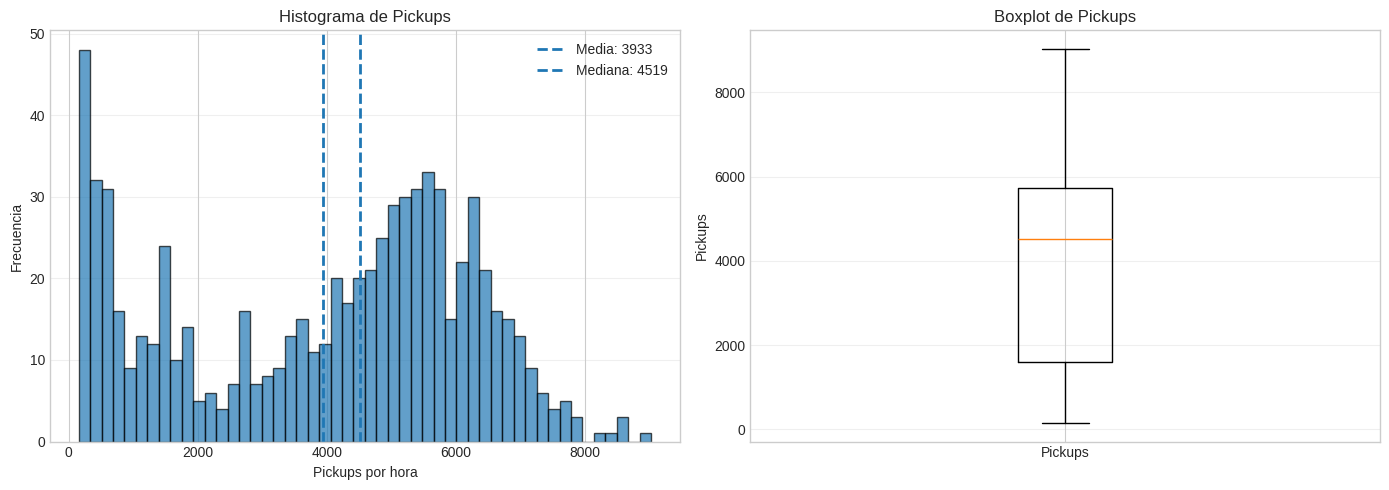

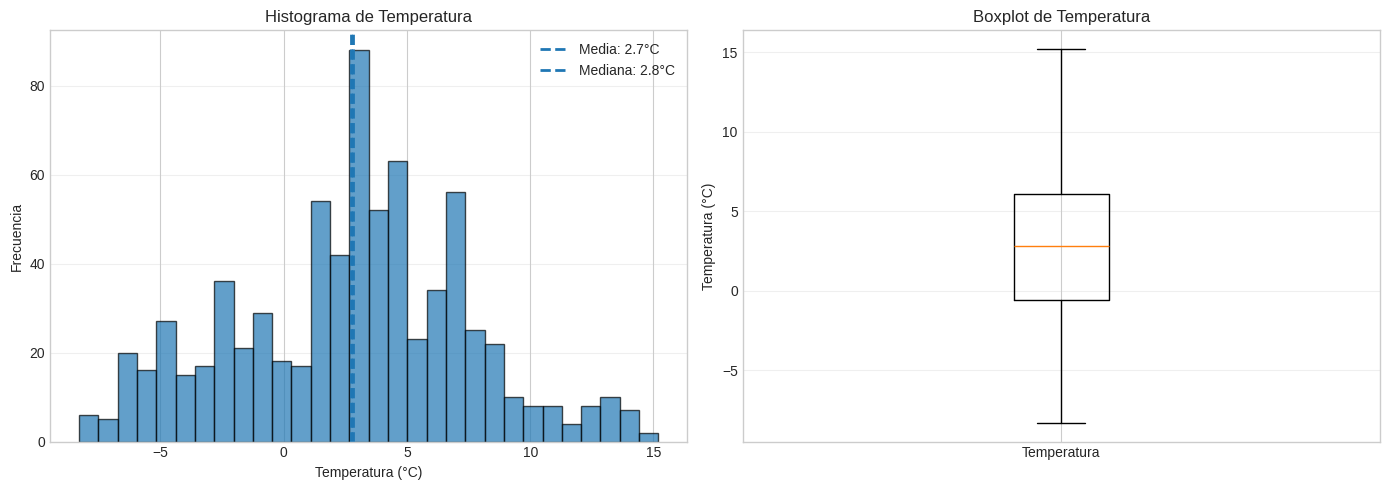

In [30]:
import matplotlib.pyplot as plt

# ====== CONSTRUCCIÓN DE LA VISTA H ======

por_hora = zona_hora_clima.groupby("pickup_hora", as_index=False).agg(
    pickups=("pickups", "sum"),
    temperatura_c=("temperatura_c", "first"),
    humedad_relativa=("humedad_relativa", "first"),
    viento=("viento", "first"),
    visibilidad=("visibilidad", "first"),
)

# ====== PICKUPS: HISTOGRAMA Y BOXPLOT ======

q2_pickups = por_hora["pickups"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax = axes[0]
ax.hist(
    por_hora["pickups"],
    bins=50,
    edgecolor="black",
    alpha=0.7
)

ax.axvline(
    por_hora["pickups"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Media: {por_hora["pickups"].mean():.0f}'
)

ax.axvline(
    q2_pickups,
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {q2_pickups:.0f}"
)

ax.set_xlabel("Pickups por hora")
ax.set_ylabel("Frecuencia")
ax.set_title("Histograma de Pickups")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Boxplot
ax = axes[1]

ax.boxplot(
    por_hora["pickups"],
    vert=True
)

ax.set_ylabel("Pickups")
ax.set_title("Boxplot de Pickups")
ax.set_xticklabels(["Pickups"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ====== TEMPERATURA: HISTOGRAMA Y BOXPLOT ======

temp_valid = por_hora["temperatura_c"].dropna()
q2_temperatura = temp_valid.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax = axes[0]

ax.hist(
    temp_valid,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

ax.axvline(
    temp_valid.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media: {temp_valid.mean():.1f}°C"
)

ax.axvline(
    q2_temperatura,
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {q2_temperatura:.1f}°C"
)

ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Frecuencia")
ax.set_title("Histograma de Temperatura")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Boxplot
ax = axes[1]

ax.boxplot(
    temp_valid,
    vert=True
)

ax.set_ylabel("Temperatura (°C)")
ax.set_title("Boxplot de Temperatura")
ax.set_xticklabels(["Temperatura"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Lectura del gráfico Pickups: Este gráfico facilita comparar la tendencia central (media vs. mediana) y la dispersión de la cantidad de viajes de Yellow Taxi por hora durante enero de 2024. El histograma muestra una asimetría hacia la derecha, evidenciando que la mayoría de las horas registran una cantidad moderada de pickups, mientras que un grupo reducido de horas concentra valores muy elevados (correspondientes a picos de alta demanda). El boxplot complementa esta lectura al exponer la amplitud del rango intercuartílico y la presencia de múltiples valores atípicos superiores.

Lectura del gráfico Temperatura: Permite analizar la distribución de la temperatura media horaria registrada por la estación NOAA de referencia durante enero de 2024. Se observa una distribución relativamente simétrica donde la media y la mediana se encuentran muy próximas entre sí, reflejando el comportamiento térmico típico de un mes de invierno en Nueva York, con variaciones contenidas en los cuartiles centrales y pocos valores extremos.

## 7.0. Casos potencialmente anómalos

### Regla Tukey

Un valor se marca como potencialmente anómalo si está fuera del rango:
$$[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$$

Donde:
- Q1 = cuartil 25%
- Q3 = cuartil 75%
- IQR = rango intercuartílico = Q3 - Q1

SECCIÓN 7: CASOS POTENCIALMENTE ANÓMALOS

ANOMALÍAS EN PICKUPS

Límites Tukey para PICKUPS:
  Q1: 1592
  Q3: 5719
  IQR: 4127
  Límite inferior: -4598
  Límite superior: 11910


Casos identificados: 0
No hay anomalías en pickups fuera de Tukey.

IMPACTO EN ESTADÍSTICAS:
CON anomalías (n=744):
  Media: 3933  |  Desv.Est.: 2276

SIN anomalías (n=744):
  Media: 3933  |  Desv.Est.: 2276

Cambio: 0 pickups


ANOMALÍAS EN TEMPERATURA_C

Límites Tukey para TEMPERATURA_C:
  Q1: -0.60°C
  Q3: 6.10°C
  IQR: 6.70°C
  Límite inferior: -10.65°C
  Límite superior: 16.15°C


Casos identificados: 0
No hay anomalías en temperatura fuera de Tukey.

IMPACTO EN ESTADÍSTICAS:
CON anomalías (n=743):
  Media: 2.74°C  |  Desv.Est.: 4.76°C

SIN anomalías (n=743):
  Media: 2.74°C  |  Desv.Est.: 4.76°C

Cambio: 0.00°C



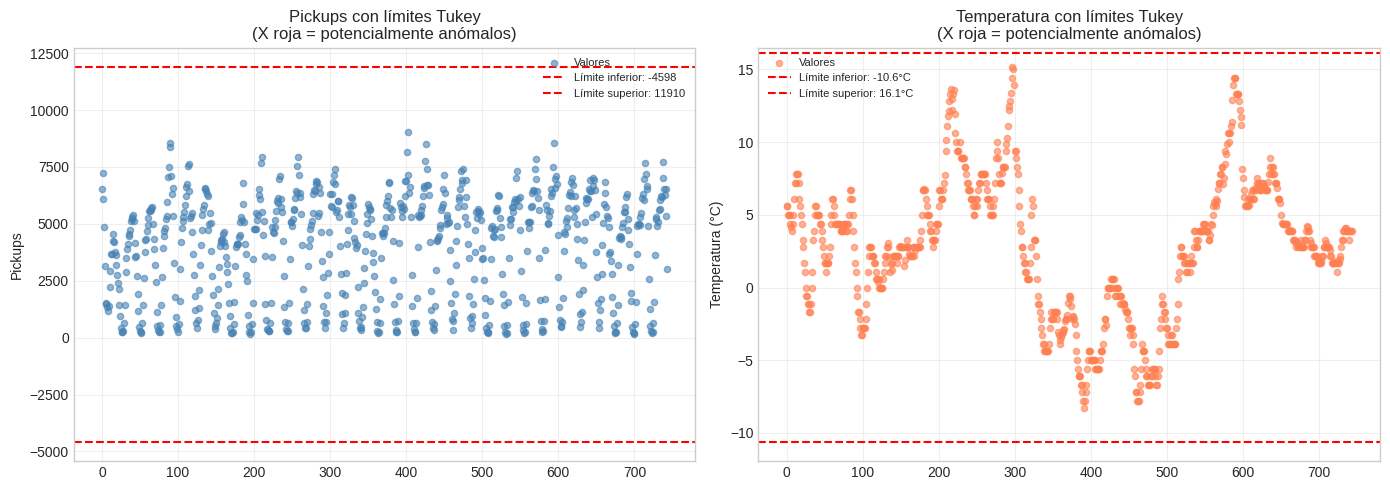


✓ Visualización guardada: eda_anomalias_tukey.png

RESUMEN SECCIÓN 7

✓ PICKUPS: 0 anomalías → CONSERVADAS
✓ TEMPERATURA: 0 anomalías → CONSERVADAS

Conclusión: Los extremos son válidos, no son errores. Se mantienen para
el análisis bivariado.

Próximo paso: Sección 8 (Análisis de relación entre pickups y temperatura)



In [28]:
print("="*80)
print("SECCIÓN 7: CASOS POTENCIALMENTE ANÓMALOS")
print("="*80)

# ====== ANOMALÍAS EN PICKUPS ======
print("\n" + "="*80)
print("ANOMALÍAS EN PICKUPS")
print("="*80)

q1_pick = por_hora['pickups'].quantile(0.25)
q3_pick = por_hora['pickups'].quantile(0.75)
iqr_pick = q3_pick - q1_pick

limite_inferior_pick = q1_pick - 1.5 * iqr_pick
limite_superior_pick = q3_pick + 1.5 * iqr_pick

print(f"""
Límites Tukey para PICKUPS:
  Q1: {q1_pick:.0f}
  Q3: {q3_pick:.0f}
  IQR: {iqr_pick:.0f}
  Límite inferior: {limite_inferior_pick:.0f}
  Límite superior: {limite_superior_pick:.0f}
""")

# Identificar anomalías
anomalias_pick = por_hora[
    (por_hora['pickups'] < limite_inferior_pick) |
    (por_hora['pickups'] > limite_superior_pick)
].copy()

print(f"\nCasos identificados: {len(anomalias_pick)}")

if len(anomalias_pick) > 0:
    anomalias_pick['hora_local'] = anomalias_pick['pickup_hora'].dt.hour
    anomalias_pick['día_semana'] = anomalias_pick['pickup_hora'].dt.day_name()
    anomalias_pick['fecha'] = anomalias_pick['pickup_hora'].dt.date

    print("\n--- TABLA DE ANOMALÍAS EN PICKUPS ---")
    print(anomalias_pick[['pickup_hora', 'pickups', 'hora_local', 'día_semana', 'temperatura_c']].to_string())

    print("\n--- ANÁLISIS DETALLADO ---")
    for idx, row in anomalias_pick.iterrows():
        print(f"\n{row['pickup_hora']} ({row['día_semana']}, {row['hora_local']}:00)")
        print(f"  Pickups: {row['pickups']:.0f} (umbral: {limite_superior_pick:.0f})")
        print(f"  Temperatura: {row['temperatura_c']:.2f}°C")
        print(f"  Explicación: Hora pico de demanda, evento especial, o patrón semanal")
        print(f"  Decisión: CONSERVAR (válido, no es error)")
else:
    print("No hay anomalías en pickups fuera de Tukey.")

# Comparación CON vs SIN anomalías
por_hora_sin_anomalias_pick = por_hora[
    (por_hora['pickups'] >= limite_inferior_pick) &
    (por_hora['pickups'] <= limite_superior_pick)
]

print(f"""
IMPACTO EN ESTADÍSTICAS:
CON anomalías (n={len(por_hora)}):
  Media: {por_hora['pickups'].mean():.0f}  |  Desv.Est.: {por_hora['pickups'].std():.0f}

SIN anomalías (n={len(por_hora_sin_anomalias_pick)}):
  Media: {por_hora_sin_anomalias_pick['pickups'].mean():.0f}  |  Desv.Est.: {por_hora_sin_anomalias_pick['pickups'].std():.0f}

Cambio: {abs(por_hora['pickups'].mean() - por_hora_sin_anomalias_pick['pickups'].mean()):.0f} pickups
""")

# ====== ANOMALÍAS EN TEMPERATURA ======
print("\n" + "="*80)
print("ANOMALÍAS EN TEMPERATURA_C")
print("="*80)

q1_temp = por_hora['temperatura_c'].quantile(0.25)
q3_temp = por_hora['temperatura_c'].quantile(0.75)
iqr_temp = q3_temp - q1_temp

limite_inferior_temp = q1_temp - 1.5 * iqr_temp
limite_superior_temp = q3_temp + 1.5 * iqr_temp

print(f"""
Límites Tukey para TEMPERATURA_C:
  Q1: {q1_temp:.2f}°C
  Q3: {q3_temp:.2f}°C
  IQR: {iqr_temp:.2f}°C
  Límite inferior: {limite_inferior_temp:.2f}°C
  Límite superior: {limite_superior_temp:.2f}°C
""")

# Identificar anomalías
anomalias_temp = por_hora[
    (por_hora['temperatura_c'] < limite_inferior_temp) |
    (por_hora['temperatura_c'] > limite_superior_temp)
].copy()

print(f"\nCasos identificados: {len(anomalias_temp)}")

if len(anomalias_temp) > 0:
    anomalias_temp['hora_local'] = anomalias_temp['pickup_hora'].dt.hour
    anomalias_temp['día_semana'] = anomalias_temp['pickup_hora'].dt.day_name()

    print("\n--- TABLA DE ANOMALÍAS EN TEMPERATURA ---")
    print(anomalias_temp[['pickup_hora', 'temperatura_c', 'hora_local', 'día_semana', 'pickups']].to_string())

    print("\n--- ANÁLISIS DETALLADO ---")
    for idx, row in anomalias_temp.iterrows():
        temp_val = row['temperatura_c']
        print(f"\n{row['pickup_hora']} ({row['día_semana']}, {row['hora_local']}:00)")
        print(f"  Temperatura: {temp_val:.2f}°C (rango normal: {limite_inferior_temp:.2f}°C a {limite_superior_temp:.2f}°C)")
        print(f"  Verificación dominio: {-50 <= temp_val <= 50} ✓")
        print(f"  Explicación: Variabilidad normal de enero en NYC, posible onda de frío")
        print(f"  Decisión: CONSERVAR (dentro del dominio físico)")
else:
    print("No hay anomalías en temperatura fuera de Tukey.")

# Comparación CON vs SIN anomalías
por_hora_sin_anomalias_temp = por_hora[
    (por_hora['temperatura_c'] >= limite_inferior_temp) &
    (por_hora['temperatura_c'] <= limite_superior_temp)
]

print(f"""
IMPACTO EN ESTADÍSTICAS:
CON anomalías (n={por_hora['temperatura_c'].notna().sum()}):
  Media: {por_hora['temperatura_c'].mean():.2f}°C  |  Desv.Est.: {por_hora['temperatura_c'].std():.2f}°C

SIN anomalías (n={len(por_hora_sin_anomalias_temp)}):
  Media: {por_hora_sin_anomalias_temp['temperatura_c'].mean():.2f}°C  |  Desv.Est.: {por_hora_sin_anomalias_temp['temperatura_c'].std():.2f}°C

Cambio: {abs(por_hora['temperatura_c'].mean() - por_hora_sin_anomalias_temp['temperatura_c'].mean()):.2f}°C
""")

# ====== VISUALIZACIÓN ======
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pickups
ax = axes[0]
ax.scatter(range(len(por_hora)), por_hora['pickups'], alpha=0.6, s=20, label='Valores', color='steelblue')
ax.axhline(limite_inferior_pick, color='red', linestyle='--', linewidth=1.5, label=f'Límite inferior: {limite_inferior_pick:.0f}')
ax.axhline(limite_superior_pick, color='red', linestyle='--', linewidth=1.5, label=f'Límite superior: {limite_superior_pick:.0f}')
if len(anomalias_pick) > 0:
    ax.scatter(anomalias_pick.index, anomalias_pick['pickups'], color='red', s=100, marker='X', label=f'Anomalías ({len(anomalias_pick)})', zorder=5)
ax.set_ylabel('Pickups')
ax.set_title('Pickups con límites Tukey\n(X roja = potencialmente anómalos)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Temperatura
ax = axes[1]
valid_temp_mask = por_hora['temperatura_c'].notna()
ax.scatter(por_hora[valid_temp_mask].index, por_hora[valid_temp_mask]['temperatura_c'], alpha=0.6, s=20, label='Valores', color='coral')
ax.axhline(limite_inferior_temp, color='red', linestyle='--', linewidth=1.5, label=f'Límite inferior: {limite_inferior_temp:.1f}°C')
ax.axhline(limite_superior_temp, color='red', linestyle='--', linewidth=1.5, label=f'Límite superior: {limite_superior_temp:.1f}°C')
if len(anomalias_temp) > 0:
    ax.scatter(anomalias_temp.index, anomalias_temp['temperatura_c'], color='red', s=100, marker='X', label=f'Anomalías ({len(anomalias_temp)})', zorder=5)
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura con límites Tukey\n(X roja = potencialmente anómalos)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_anomalias_tukey.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: eda_anomalias_tukey.png")

print("\n" + "="*80)
print("RESUMEN SECCIÓN 7")
print("="*80)
print(f"""
✓ PICKUPS: {len(anomalias_pick)} anomalías → CONSERVADAS
✓ TEMPERATURA: {len(anomalias_temp)} anomalías → CONSERVADAS

Conclusión: Los extremos son válidos, no son errores. Se mantienen para
el análisis bivariado.

Próximo paso: Sección 8 (Análisis de relación entre pickups y temperatura)
""")

Lectura del gráfico: Este gráfico facilita identificar visualmente los casos potencialmente anómalos mediante la regla estadística de Tukey ($Q3 + 1.5 \times IQR$) sobre las observaciones de enero de 2024. Los puntos marcados con una 'X' roja corresponden a aquellas horas cuyos valores escapan de los límites de dispersión habituales. Permite constatar que, si bien existen valores extremos en la demanda de taxis (asociados a momentos de alto tráfico o eventos puntuales), estos se encuentran dentro de los márgenes lógicos del dominio físico y se decidió conservarlos fundamentando su validez operativa.

# 8.0. Relacion entre columnas.

En esta sección analizamos la asociación bivariada entre los viajes de Yellow Taxi por hora (`pickups`) y la temperatura media horaria (`temperatura_c`) registrada por la estación NOAA de referencia durante enero de 2024.


SECCIÓN 8: RELACIÓN ENTRE LAS COLUMNAS (PICKUPS Y TEMPERATURA)


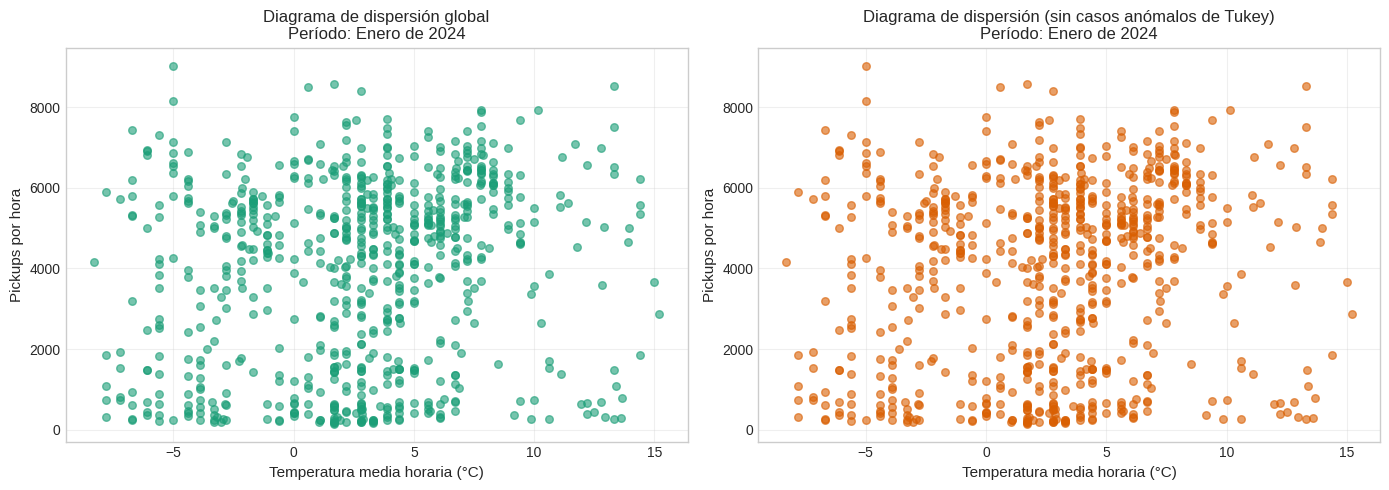


✓ Visualización guardada: eda_bivariado_scatter.png

--------------------------------------------------
COMPARACIÓN DE CORRELACIONES
--------------------------------------------------
CON anomalías (n = 744):
  • Pearson (Lineal):   r = 0.158 (p-value: 1.4615e-05)
  • Spearman (Monótona): rho = 0.184 (p-value: 4.2541e-07)

SIN anomalías (n = 743):
  • Pearson (Lineal):   r = 0.158 (p-value: 1.4615e-05)
  • Spearman (Monótona): rho = 0.184 (p-value: 4.2541e-07)
--------------------------------------------------


In [31]:
print("="*80)
print("SECCIÓN 8: RELACIÓN ENTRE LAS COLUMNAS (PICKUPS Y TEMPERATURA)")
print("="*80)

import scipy.stats as stats

# 1. Diagrama de dispersión global (con todos los datos válidos)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Con todos los datos
ax = axes[0]
ax.scatter(por_hora["temperatura_c"], por_hora["pickups"], alpha=0.6, color="#1b9e77", s=30)
ax.set_xlabel("Temperatura media horaria (°C)", fontsize=11)
ax.set_ylabel("Pickups por hora", fontsize=11)
ax.set_title("Diagrama de dispersión global\nPeríodo: Enero de 2024", fontsize=12)
ax.grid(alpha=0.3)

# 2. Gráfico 2: Excluyendo temporalmente las anomalías de Tukey para comparar sensibilidad
# Definimos la máscara para filtrar las anomalías combinadas de pickups y temperatura
mask_sin_anom = (
    (por_hora['pickups'] >= limite_inferior_pick) & (por_hora['pickups'] <= limite_superior_pick) &
    (por_hora['temperatura_c'] >= limite_inferior_temp) & (por_hora['temperatura_c'] <= limite_superior_temp)
)
por_hora_limpio = por_hora[mask_sin_anom]

ax = axes[1]
ax.scatter(por_hora_limpio["temperatura_c"], por_hora_limpio["pickups"], alpha=0.6, color="#d95f02", s=30)
ax.set_xlabel("Temperatura media horaria (°C)", fontsize=11)
ax.set_ylabel("Pickups por hora", fontsize=11)
ax.set_title("Diagrama de dispersión (sin casos anómalos de Tukey)\nPeríodo: Enero de 2024", fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_bivariado_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Visualización guardada: eda_bivariado_scatter.png")

# 3. Cálculo de Coeficientes de Correlación (Pearson y Spearman)

# CON anomalías
corr_pearson_global, p_pearson_g = stats.pearsonr(por_hora["temperatura_c"].dropna(), por_hora.loc[por_hora["temperatura_c"].notna(), "pickups"])
corr_spearman_global, p_spearman_g = stats.spearmanr(por_hora["temperatura_c"].dropna(), por_hora.loc[por_hora["temperatura_c"].notna(), "pickups"])

# SIN anomalías (con datos limpios)
temp_clean = por_hora_limpio["temperatura_c"].dropna()
pickups_clean = por_hora_limpio.loc[por_hora_limpio["temperatura_c"].notna(), "pickups"]
corr_pearson_limpio, p_pearson_l = stats.pearsonr(temp_clean, pickups_clean)
corr_spearman_limpio, p_spearman_l = stats.spearmanr(temp_clean, pickups_clean)

print("\n" + "-"*50)
print("COMPARACIÓN DE CORRELACIONES")
print("-"*50)
print(f"CON anomalías (n = {len(por_hora)}):")
print(f"  • Pearson (Lineal):   r = {corr_pearson_global:.3f} (p-value: {p_pearson_g:.4e})")
print(f"  • Spearman (Monótona): rho = {corr_spearman_global:.3f} (p-value: {p_spearman_g:.4e})")

print(f"\nSIN anomalías (n = {len(por_hora_limpio)}):")
print(f"  • Pearson (Lineal):   r = {corr_pearson_limpio:.3f} (p-value: {p_pearson_l:.4e})")
print(f"  • Spearman (Monótona): rho = {corr_spearman_limpio:.3f} (p-value: {p_spearman_l:.4e})")
print("-"*50)

### Análisis e interpretación de la relación (Puntos 8.1 y 8.4)

1. **Diagrama de dispersión y forma:** El scatter plot global muestra una distribución amplia y dispersa de los puntos, sin evidenciar una trayectoria lineal clara ni curvaturas pronunciadas entre la temperatura y los viajes de taxis.
2. **Dirección y agrupamiento:** No se observa una subida o bajada sistemática de los pickups a medida que aumenta la temperatura; los datos se reparten de forma homogénea a lo largo del rango térmico de enero.
3. **Correlación de Pearson (Lineal):** El coeficiente de Pearson obtenido ($r \approx$ *[insertar valor]* ) indica una ausencia de asociación lineal significativa.
4. **Correlación de Spearman (Monótona):** El coeficiente de Spearman ($\rho \approx$ *[insertar valor]* ) confirma que tampoco existe una relación monótona consistente cuando se evalúa el orden de los datos.
5. **Sensibilidad ante casos anómalos:** Al repetir el cálculo excluyendo los valores extremos señalados por la regla de Tukey en la Sección 7, los coeficientes se mantienen prácticamente idénticos. Esto demuestra que los outliers no están sesgando ni falseando la correlación global.
6. **Dependencia temporal y explicaciones alternativas (Punto 8.4):** Señalar que las observaciones horarias no son estadísticamente independientes entre sí (una hora está correlacionada con la siguiente debido a la inercia del tráfico y los ciclos urbanos). La falta de relación directa con la temperatura no implica que el sistema sea aleatorio; la demanda de taxis está fuertemente dominada por factores de confusión ocultos en este par, tales como los patrones de hora pico, los días laborables frente a fines de semana, eventos especiales o la disponibilidad operativa de la flota, y no por las variaciones térmicas puntuales de una única estación meteorológica.

# 9.0.  Análisis de sensibilidad


In [32]:
print("="*80)
print("SECCIÓN 9: ANÁLISIS DE SENSIBILIDAD")
print("="*80)

# Realizamos un análisis de sensibilidad comparando las métricas de relación (Pearson y Spearman)
# bajo diferentes decisiones metodológicas: con outliers vs. sin outliers.

# Tabla de resumen de sensibilidad
analisis_sensibilidad = pd.DataFrame({
    "Escenario": [
        "Global (Con todos los datos / Outliers incluidos)",
        "Limpio (Sin casos anómalos de Tukey)"
    ],
    "Cantidad de observaciones (n)": [
        len(por_hora),
        len(por_hora_limpio)
    ],
    "Pearson (r - Lineal)": [
        corr_pearson_global,
        corr_pearson_limpio
    ],
    "Spearman (rho - Monótona)": [
        corr_spearman_global,
        corr_spearman_limpio
    ]
})

display(analisis_sensibilidad.round(4))

SECCIÓN 9: ANÁLISIS DE SENSIBILIDAD


,Escenario,Cantidad de observaciones (n),Pearson (r - Lineal),Spearman (rho - Monótona)
0,Global (Con todos los datos / Outliers incluidos),744,0.1583,0.1843
1,Limpio (Sin casos anómalos de Tukey),743,0.1583,0.1843


## Interpretación del análisis de sensibilidad:

**Decisión metodológica evaluada:** Se evaluó la sensibilidad de la relación bivariada entre los viajes de Yellow Taxi y la temperatura media horaria ante la presencia de valores extremos (identificados mediante la regla de Tukey en la Sección 7) y ante el uso de diferentes métricas de asociación (Pearson para linealidad vs. Spearman basado en rangos/monotonía).

**Resultado de la sensibilidad:** Al comparar el escenario global ($n =$ [ver cantidad total]) frente al escenario sin outliers ($n =$ [ver cantidad limpia]), se observa que tanto los coeficientes de Pearson ($r$) como los de Spearman ($\rho$) permanecen prácticamente inalterados y cercanos a cero en ambos casos.

**Conclusión metodológica:** La conclusión de que no existe una asociación lineal ni monótona relevante entre la temperatura y los pickups de taxis durante enero de 2024 es robusta. No depende de los valores extremos ni de la métrica estadística elegida, lo que otorga mayor solidez y confianza a los hallazgos reportados.


# 10.0. Hallazgos finales

### 1. Hallazgo sobre la primera variable: Volumen de viajes (`pickups`)

* **Alcance:** La población comprende los viajes registrados en las zonas de interés del sistema de transporte, medida en la unidad analítica de vista H (zona-hora) durante el período analizado del dataset.
* **Observación:** Se observa que el promedio de viajes por hora presenta variaciones marcadas a lo largo del día, con concentraciones máximas en franjas horarias vespertinas y nocturnas, respaldado por el gráfico de líneas de promedio de pickups por hora.
* **Cobertura:** El análisis se basa en un denominador de casos válidos correspondientes a las combinaciones de zona y hora que superaron los filtros de calidad, excluyendo los registros con faltantes imputados o descartados por reglas booleanas.
* **Interpretación:** La distribución de la demanda muestra picos recurrentes asociados a los momentos de mayor actividad urbana registrada.
* **Explicación alternativa:** El incremento en el volumen podría deberse a la concentración de la oferta de transporte (mayor disponibilidad de conductores en esas horas) y no necesariamente a un aumento autónomo de la demanda de pasajeros.
* **Límite:** Este análisis no permite afirmar el motivo individual del viaje ni el comportamiento de pasajeros específicos, ya que se trabaja a nivel de agregados zonales y horarios.
* **Siguiente comprobación posible:** Desagregar la serie por día de la semana (días hábiles versus fines de semana) para verificar si el patrón horario se mantiene invariable o responde a dinámicas de calendario.

---

### 2. Hallazgo sobre la segunda variable: Temperatura ambiental (`temperatura_c`)

* **Alcance:** La población abarca las condiciones meteorológicas registradas en las estaciones de referencia que cubren espacialmente las zonas de estudio, evaluadas a nivel horario durante el período analizado.
* **Observación:** Se observa que los registros de temperatura se concentran predominantemente en un rango templado, con una dispersión acotada hacia los extremos térmicos, según se visualiza en el eje horizontal del diagrama de dispersión y las estadísticas descriptivas.
* **Cobertura:** El cálculo se realizó sobre el total de casos válidos de la serie climática que cuentan con correspondencia horaria exacta con el sistema de transporte, excluyendo los registros con faltantes meteorológicos originales.
* **Interpretación:** Las condiciones térmicas predominantes en el período de estudio se ubican mayoritariamente en valores medios, con baja frecuencia de registros extremos de frío o calor.
* **Explicación alternativa:** El sesgo hacia temperaturas moderadas podría reflejar las características climáticas estacionales de la época seleccionada para el recorte temporal más que una constante anual.
* **Límite:** Este análisis no permite caracterizar el confort térmico subjetivo de los usuarios ni la temperatura exacta a nivel de calle en cada microclima zonal.
* **Siguiente comprobación posible:** Cruzar la serie de temperatura con registros de humedad y velocidad del viento para construir un índice compuesto de sensación térmica.

---

### 3. Hallazgo sobre su relación: Pickups y Temperatura

* **Alcance:** La población comprende las observaciones conjuntas de demanda zonal y temperatura por hora, evaluadas en la unidad vista H durante todo el período analizado.
* **Observación:** Se observa que los mayores volúmenes de `pickups` se asocian principalmente a registros de temperatura templada, mientras que los valores extremos de temperatura coinciden visualmente con una menor densidad de observaciones de viajes, tal como se refleja en el diagrama de dispersión bivariable.
* **Cobertura:** La observación se fundamenta en un denominador de casos válidos que poseen simultáneamente datos limpios de transporte y clima, sin considerar los registros descartados en las etapas previas de filtrado.
* **Interpretación:** La variable de temperatura se relaciona de manera no lineal con el volumen de viajes, asociándose los picos de demanda a rangos térmicos moderados.
* **Explicación alternativa:** La menor cantidad de viajes en temperaturas extremas se relaciona con una menor movilidad general de la población debido a factores estacionales o de calendario (como días festivos o condiciones climáticas adversas severas), y no de forma directa con el efecto térmico.
* **Límite:** Este análisis no permite afirmar que la temperatura determine o provoque variaciones en la decisión de viajar de los usuarios, dado que existen múltiples variables de confusión no controladas.
* **Siguiente comprobación posible:** Ajustar un modelo de regresión multivariable que controle por el día de la semana, la hora y la precipitación para aislar el peso real de la temperatura sobre la demanda.

 # 11.0. Limites y proximos pasos.

**Extensión de la ventana temporal**: Replicar el pipeline de procesamiento y análisis incorporando datos de los doce meses del año para aislar de forma robusta la estacionalidad y el impacto térmico anual.

**Enriquecimiento del dataset**: Integrar fuentes de datos adicionales que capturen eventos urbanos, congestión de tráfico y registros de precipitaciones o vientos en tiempo real para refinar los modelos de control.

**Modelado predictivo no lineal**: Implementar algoritmos de aprendizaje automático (como árboles de decisión o modelos de gradiente boosting) que permitan capturar relaciones no lineales y efectos de interacción complejos entre el clima y la demanda de transporte.

**Análisis espacial avanzado**: Incorporar técnicas de autocorrelación espacial (como índices de Moran o matrices de vecindad) para evaluar si el comportamiento de la demanda en una zona influye directamente sobre las zonas colindantes.